# E-Commerce Recommendation System
**Architecture:** Market Basket Analysis via Apriori Algorithm


### Import essential libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Loading the dataset

In [ ]:
df=pd.read_csv('retail_customer_segmentation.csv')
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France



##  Exploratory Data Analysis (EDA)
Before building our Apriori recommendation model, we must understand the baseline business metrics.
Our EDA will answer three core business questions:
1. **Data Integrity:** Dealing with missing or dirty data
2. **Product Performance:** What are the top-selling products overall?
3. **Geographical & Temporal Trends:** How do sales distribute across countries and time?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


* `Dropping Null Customer IDs:` In e-commerce data, anonymous transactions (guest checkouts where IDs aren't logged) are common. However, for both RFM clustering and Market Basket Analysis, the core unit of measurement is the individual customer and their specific cart. If we cannot tie a transaction to a specific entity, that row is useless noise for our specific models.

*  We are removing the records where ever the **Customer ID** has null value

In [ ]:
df_cleaned=df.dropna(subset=['Customer ID']).copy()
print('Initial Records',df.shape[0])
print('Cleaned records',df_cleaned.shape[0])
print('Dataset Info\n')
df_cleaned.info()

Initial Records 1067371
Cleaned records 824364
Dataset Info

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


* No more null values in the dataset

`Filtering Quantity and Price (> 0):` This dataset contains operational artifacts.

* Negative Quantity: This represents a return, cancellation, or stock adjustment. If we include these, our recommendation engine might learn to "recommend" a return alongside a purchase.

* Zero Price: These are usually system errors, lost items, or promotional freebies. They skew the "Monetary" value in RFM and don't represent genuine purchasing intent for market basket analysis.

In [ ]:
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]
print('Cleaned records',df_cleaned.shape[0],'\n')
print(df_cleaned.info())

Cleaned records 805549 

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  object 
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB
None


`InvoiceDate`: InvoiceDate is currently an object (string). Must be converted to datetime to calculate Recency (time deltas) and sequence user journeys.

`Customer ID`: Customer ID is loaded as a float. IDs are categorical labels, not continuous variables. We cast to integer to remove decimals, then to string

In [ ]:
# Convert InvoiceDate from string to datetime
df_cleaned['InvoiceDate']=pd.to_datetime(df_cleaned['InvoiceDate'])
print('InvoiceDate (Datatype): ',df_cleaned['InvoiceDate'].dtype)

#Clean up Customer ID format (convert to string)
# Use 'Int64' as a string to reference the pandas nullable integer type
df_cleaned['Customer ID']=df_cleaned['Customer ID'].astype(int).astype(str)
print('Customer ID (Datatype): ',df_cleaned['Customer ID'].dtype)

InvoiceDate (Datatype):  datetime64[ns]
Customer ID (Datatype):  object


### Feature Engineering:
* Pre-calculating the total revenue per line item for later Monetary aggregations.

In [ ]:
df_cleaned['Totalprice']=df_cleaned['Quantity']*df_cleaned['Price']
df_cleaned.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Totalprice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [ ]:
df_cleaned.to_csv('Retail_train.csv',index=False)

### Baseline Business Metrics (EDA)

#### Executive Objective
Before developing and deploying a recommendation algorithm, it is critical to establish a baseline of organic purchasing behavior.

This phase focuses on:
1. **Market Dominance:** Validating the assumption that the UK is the primary revenue driver to justify a localized model.
2. **Organic Product Performance:** Identifying the highest-volume products in the target market to understand natural cart compositions.

In [ ]:
# Obtaining the country wise revenue, sorting, and resetting the index to start from 1
revenue_df = (df_cleaned.groupby('Country')['Totalprice'].sum().sort_values(ascending=False)).round(2).reset_index()
top10_countries=revenue_df.head(10)
print(f'Numer of Countries {len(revenue_df['Country'])}\n')
print(revenue_df)
print('\n=====================================================================\n')
print(f'Top 10 Countries based on Revenue Generated are;\n{top10_countries}')

Numer of Countries 41

                 Country   Totalprice
0         United Kingdom  14723147.52
1                   EIRE    621631.11
2            Netherlands    554232.34
3                Germany    431262.46
4                 France    355257.47
5              Australia    169968.11
6                  Spain    109178.53
7            Switzerland    100365.34
8                 Sweden     91549.72
9                Denmark     69862.19
10               Belgium     65753.42
11                Norway     60109.62
12              Portugal     57285.30
13                 Japan     47138.39
14       Channel Islands     44996.76
15                 Italy     32550.42
16               Finland     29925.54
17             Singapore     25317.06
18                Cyprus     24980.13
19               Austria     23613.01
20                Greece     19096.19
21                Poland     10902.45
22                Israel     10421.09
23  United Arab Emirates      9202.69
24           Unspecified   

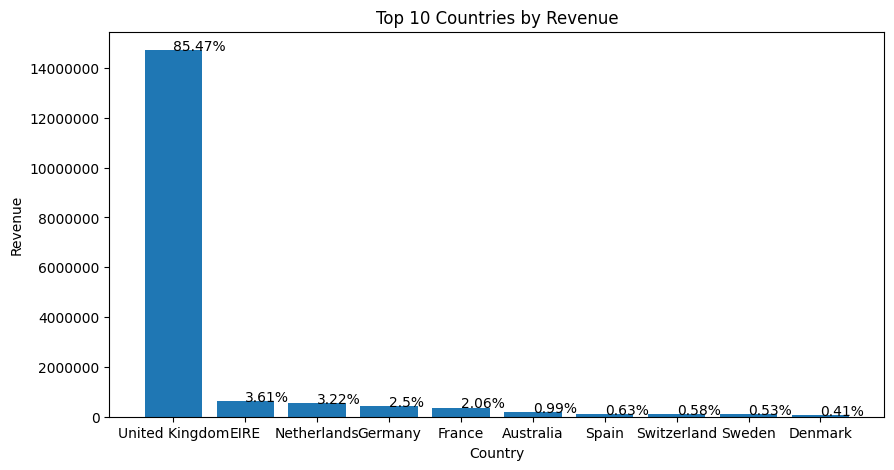

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(top10_countries['Country'], top10_countries['Totalprice'] )
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain',axis='y')
for i,value in enumerate(top10_countries['Totalprice'].values):
  percentage=top10_countries['Totalprice'][i]/sum(top10_countries['Totalprice'])*100
  plt.text(i,value,f'{percentage.round(2)}%')
plt.show()


### Key Findings
* **Market Distribution:** The data confirms the United Kingdom is the dominant market by a significant margin of which is Contributing around **85%** of revenue among top 10 countries, validating our decision to isolate the Apriori model to UK data.
* **Top Products:** The highest volume products indicate a strong customer preference for [Insert General Category, e.g., homeware/gifts/wholesale]. Notably, the top-selling item is [Insert Item Name].

In [ ]:
#Purchasing behavior varies heavily by region. A recommendation engine trained on global data gets muddy. We isolate to the core market (UK).
uk_data=df_cleaned[df_cleaned['Country']=='United Kingdom']
uk_data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Totalprice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
...,...,...,...,...,...,...,...,...,...
1067350,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804,United Kingdom,23.4
1067351,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113,United Kingdom,23.6
1067352,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113,United Kingdom,30.0
1067353,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113,United Kingdom,214.8


In [ ]:
uk_data.to_csv('UK_retaildata.csv',index=False )

In [ ]:
#uk_data=pd.read_csv('UK_retaildata.csv')
#uk_data.drop()
print(uk_data.head(5),'\n')
print(uk_data.shape)

   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  Totalprice  
0  2009-12-01 07:45:00   6.95        13085  United Kingdom        83.4  
1  2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  
2  2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  
3  2009-12-01 07:45:00   2.10        13085  United Kingdom       100.8  
4  2009-12-01 07:45:00   1.25        13085  United Kingdom        30.0   

(725250, 9)


#### Top Selling Products in the UK (In descending order of Quantity)

In [ ]:
uk_products=uk_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).reset_index()
print(uk_products)

                             Description  Quantity
0      WORLD WAR 2 GLIDERS ASSTD DESIGNS    100720
1     WHITE HANGING HEART T-LIGHT HOLDER     86327
2            PAPER CRAFT , LITTLE BIRDIE     80995
3         MEDIUM CERAMIC TOP STORAGE JAR     76919
4          ASSORTED COLOUR BIRD ORNAMENT     74256
...                                  ...       ...
5244    HEXAGONAL CRYSTAL PERFUME BOTTLE         1
5245              FLOWER SHOP DESIGN MUG         1
5246             NEW BAROQUE BLACK BOXES         1
5247      S/6 SCANDINAVIAN HEART T-LIGHT         1
5248                  OWLS CHARLOTTE BAG         1

[5249 rows x 2 columns]


* We need to know what organically sells the most before we try to build algorithms to push other products.

In [ ]:
top_products_quantity = uk_data.groupby('Description').agg({'Quantity': 'sum', 'Totalprice': 'sum'}).nlargest(10, 'Quantity').reset_index()
print('Top 10 Products in UK by Quantity\n')
print(top_products_quantity)

Top 10 Products in UK by Quantity

                          Description  Quantity  Totalprice
0   WORLD WAR 2 GLIDERS ASSTD DESIGNS    100720    22747.50
1  WHITE HANGING HEART T-LIGHT HOLDER     86327   232828.71
2         PAPER CRAFT , LITTLE BIRDIE     80995   168469.60
3      MEDIUM CERAMIC TOP STORAGE JAR     76919    80291.44
4       ASSORTED COLOUR BIRD ORNAMENT     74256   118166.64
5                 BROCADE RING PURSE      70725    14717.67
6             JUMBO BAG RED RETROSPOT     69011   124702.27
7  PACK OF 60 PINK PAISLEY CAKE CASES     45454    21865.05
8         60 TEATIME FAIRY CAKE CASES     40715    20075.37
9                SMALL POPCORN HOLDER     40001    30216.03


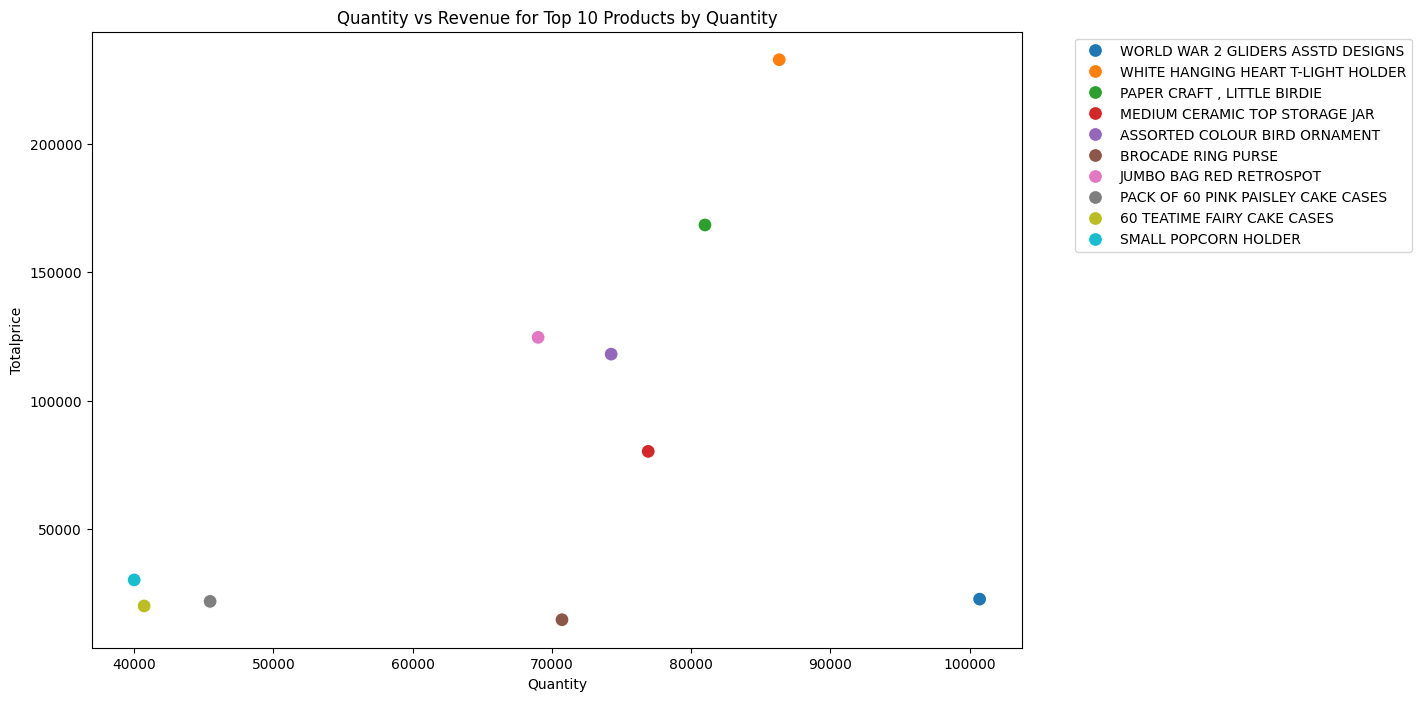

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Quantity', y='Totalprice', data=top_products_quantity, hue='Description', s=100)
plt.title('Quantity vs Revenue for Top 10 Products by Quantity')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Top 10 products based on Revenue

In [ ]:
top_products_revenue=uk_data.groupby('Description').agg({'Quantity':'sum','Totalprice':'sum'}).nlargest(10,'Totalprice').reset_index()
print('Top 10 Products in UK by Revenue\n')
print(top_products_revenue)

Top 10 Products in UK by Revenue

                          Description  Quantity  Totalprice
0            REGENCY CAKESTAND 3 TIER     20317   234185.80
1  WHITE HANGING HEART T-LIGHT HOLDER     86327   232828.71
2         PAPER CRAFT , LITTLE BIRDIE     80995   168469.60
3             JUMBO BAG RED RETROSPOT     69011   124702.27
4       ASSORTED COLOUR BIRD ORNAMENT     74256   118166.64
5                       PARTY BUNTING     21574    95093.98
6      MEDIUM CERAMIC TOP STORAGE JAR     76919    80291.44
7     PAPER CHAIN KIT 50'S CHRISTMAS      28344    76507.98
8                              Manual      9713    73663.70
9                       CHILLI LIGHTS     15517    71752.24


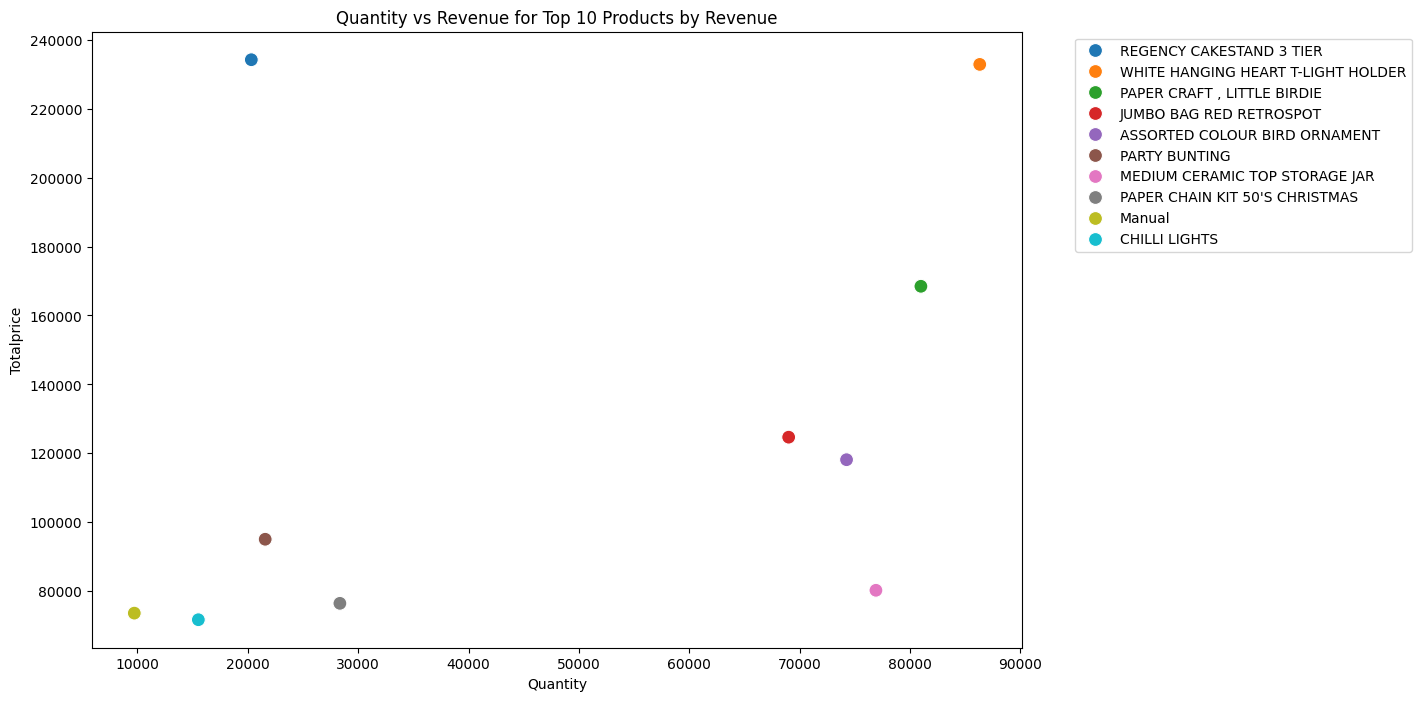

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Quantity', y='Totalprice', data=top_products_revenue, hue='Description', s=100)
plt.title('Quantity vs Revenue for Top 10 Products by Revenue')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#### Revenue vs Quantity Comparision Chart
* Barchart Represents the Revenue of Products
* Lineplot represents the Quantity of Products sold

##### Comaprision chart of Top Revenue Generated Products

/tmp/ipykernel_1450/3352700311.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


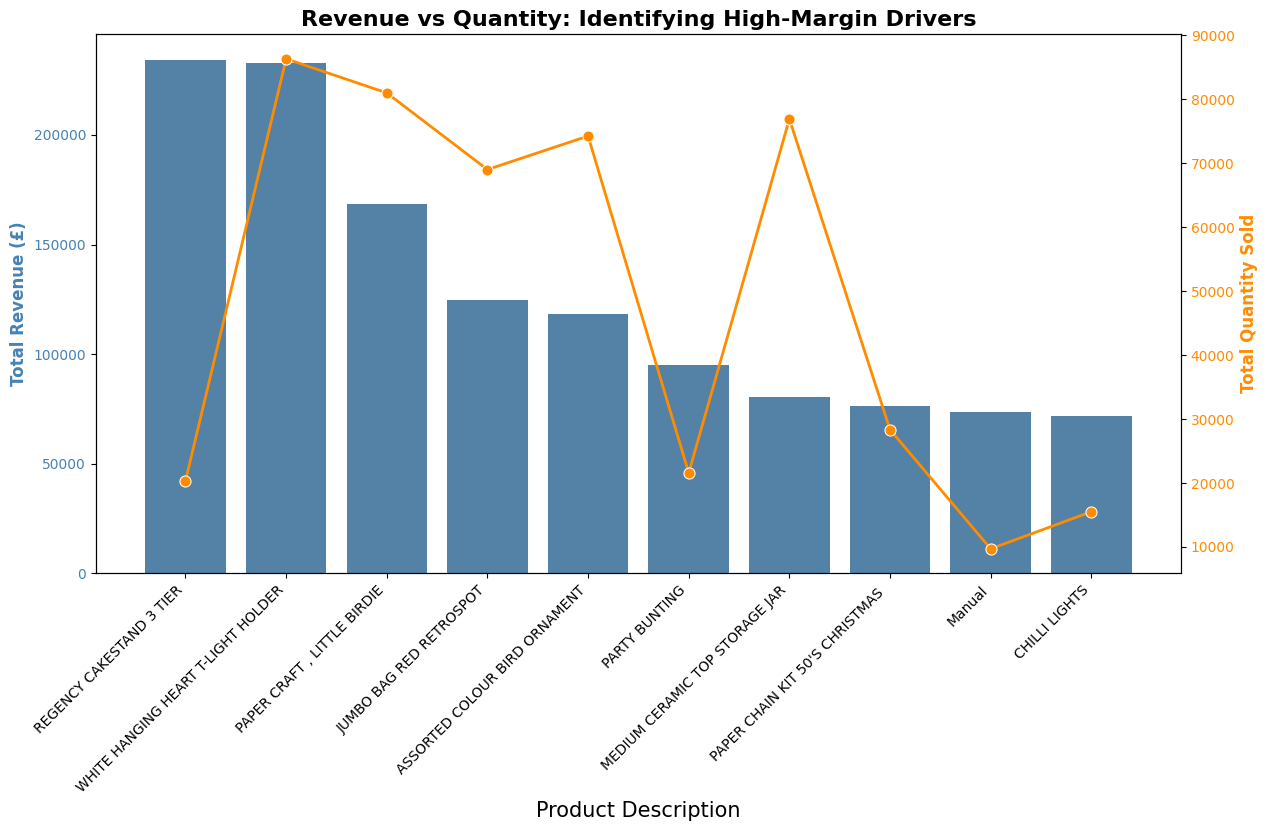

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

#Plot Revenue as a Bar Chart on ax1 (Left Y-Axis)
sns.barplot(x='Description', y='Totalprice', data=top_products_revenue, ax=ax1, color='steelblue')
ax1.set_ylabel('Total Revenue (£)', color='steelblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Product Description', fontsize=15)
ax1.tick_params(axis='y', labelcolor='steelblue')
# Rotate the long product names so they are readable
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 3. Create a secondary axis that shares the same X-axis
ax2 = ax1.twinx()

#Plot Quantity as a Line Chart on ax2 (Right Y-Axis)
sns.lineplot(x='Description', y='Quantity', data=top_products_revenue, ax=ax2, color='darkorange', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel('Total Quantity Sold', color='darkorange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Revenue vs Quantity: Identifying High-Margin Drivers', fontsize=16, fontweight='bold')
plt.show()

#### Comparision chart of top products based on Volumne

/tmp/ipykernel_1450/3735160866.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45,ha='right')


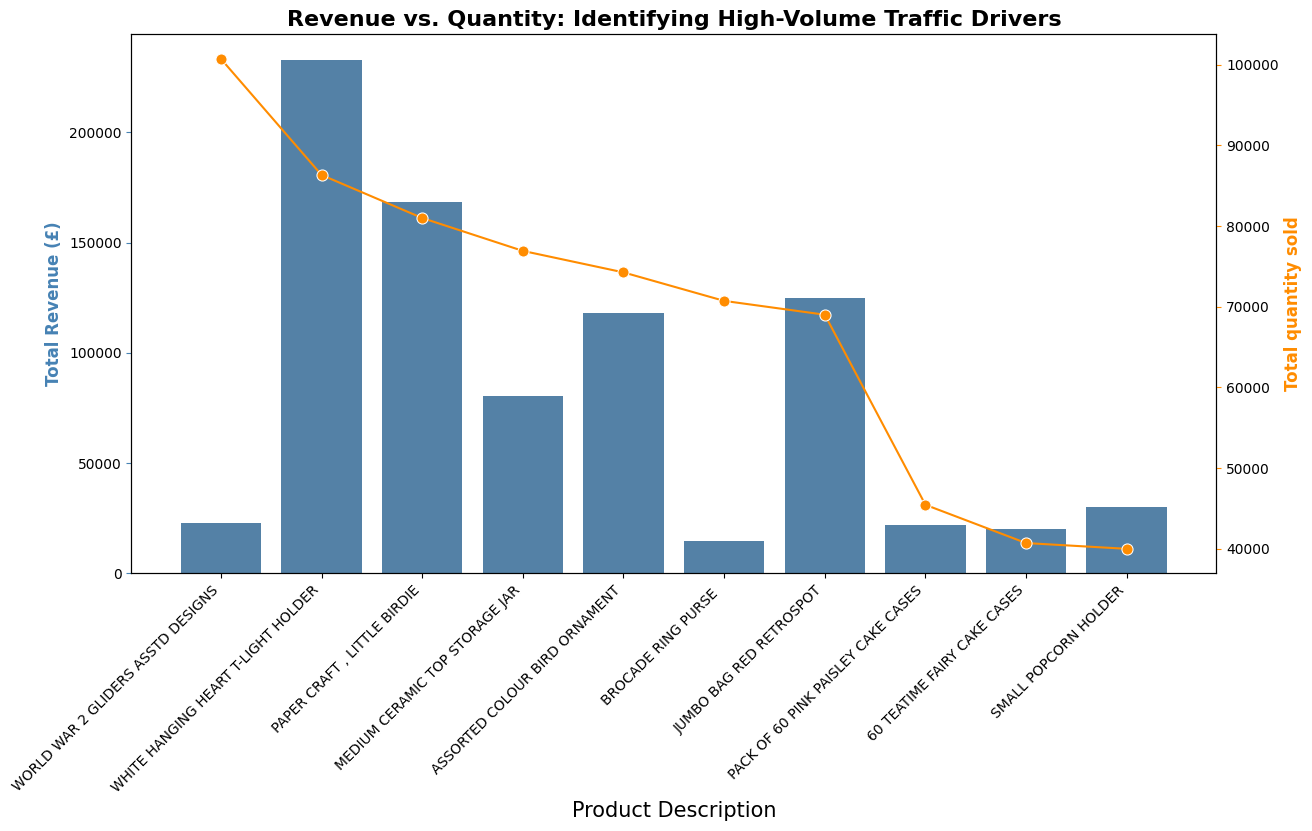

In [ ]:
fig, ax1=plt.subplots(figsize=(14,7))

#Plot Revenue as a Bar Chart on ax1 (Left Y-Axis)
sns.barplot(x='Description',y='Totalprice', data=top_products_quantity, ax=ax1, color='steelblue')
ax1.set_ylabel('Total Revenue (£)', color='steelblue', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y',color='steelblue')

ax1.set_xlabel('Product Description', fontsize=15)
ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45,ha='right')

ax2=ax1.twinx()

sns.lineplot(x='Description',y='Quantity',ax=ax2, color='darkorange',marker='o',markersize=8,data=top_products_quantity)
ax2.set_ylabel('Total quantity sold', color='darkorange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y',color='darkorange')

plt.title('Revenue vs. Quantity: Identifying High-Volume Traffic Drivers',fontsize=16,fontweight='bold')
plt.show()


### Visual Insights: Product Value Proposition & Margin Analysis

By comparing total transaction volume against total generated revenue, we can categorize our inventory into three distinct strategic groups:

**1. High-Margin Outliers (Low Volume, High Revenue)**
* *Example:* **Regency Cakestand 3 Tier**
* *Insight:* This product generates the maximum revenue across the UK market despite having one of the lowest unit sales among top performers. This indicates a premium price point and a massive profit margin. These items require minimal logistical overhead (shipping/storage) but yield maximum financial return.

**2. Low-Margin Traffic Drivers (High Volume, Low Revenue)**
* *Example:* **World War 2 Gliders Asstd Designs**
* *Insight:* This item moves incredible volume (over 100,000 units) but generates a negligible fraction of total revenue. These are extremely low-cost items. While they do not drive profitability, they represent high customer engagement and can be leveraged as gateway items to cross-sell more expensive goods.

**3. Core Revenue Anchors (High Volume, High Revenue)**
* *Examples:* **White Hanging Heart T-Light Holder**, **Paper Craft Little Birdie**, and **Jumbo Bag Red Retrospot**
* *Insight:* These are the "golden" products of the business. They achieve the rare balance of selling in massive quantities while maintaining a high enough price point to drive significant top-line revenue. Any recommendation engine or marketing campaign should heavily feature these proven anchors.

### Temporal Analysis & Purchasing Rhythms

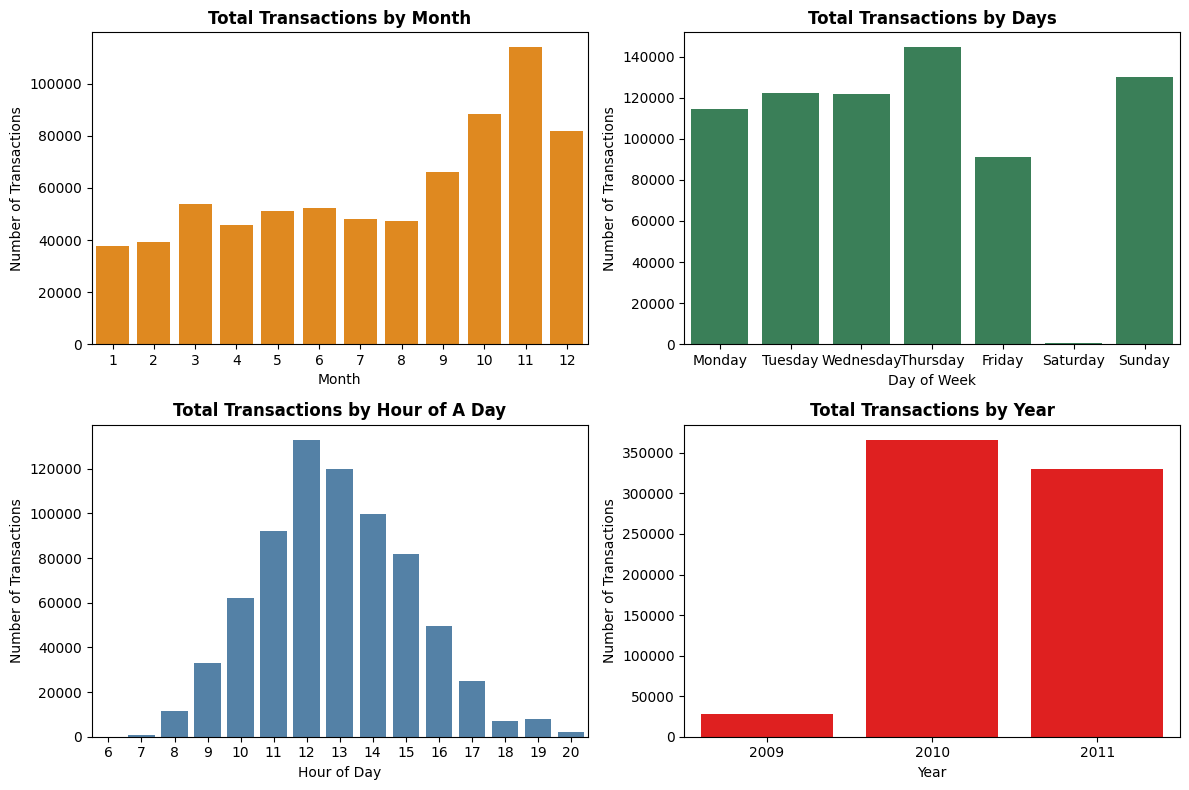

In [ ]:
uk_eda=uk_data.copy()
uk_eda

uk_eda['DayOfWeek']=uk_eda['InvoiceDate'].dt.day_name()
uk_eda['Month']=uk_eda['InvoiceDate'].dt.month
uk_eda['Year']=uk_eda['InvoiceDate'].dt.year
uk_eda['Hour']=uk_eda['InvoiceDate'].dt.hour

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.countplot(x='Month', data=uk_eda, color='darkorange' )
plt.title('Total Transactions by Month', fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Month')

plt.subplot(2,2,2)
orderofday = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='DayOfWeek',data=uk_eda, order=orderofday,color='seagreen')
plt.title('Total Transactions by Days',fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Day of Week')

plt.subplot(2,2,3)
sns.countplot(x='Hour', data=uk_eda,color='steelblue')
plt.title('Total Transactions by Hour of A Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Hour of Day')

plt.subplot(2,2,4)
sns.countplot(x='Year', data=uk_eda,color='red')
plt.title('Total Transactions by Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Year')

plt.tight_layout()

plt.show()



### Temporal Analysis & Purchasing Rhythms

#### Executive Summary
Analysis of transaction timestamps reveals distinct seasonal, weekly, and daily purchasing patterns. These metrics definitively confirm the B2B nature of our customer base and highlight critical timing windows for marketing deployment.

#### Key Insights

**1. Macro Trends: The Q4 Seasonality (Month & Year)**
* Transaction volume spikes aggressively in **November (Month 11)**, indicating a massive end-of-year purchasing rush.
* *(Note on Annual Data: 2009 volume is heavily skewed, suggesting a partial year of data capture. Reliable baselines are drawn from 2010-2011).*

**2. Micro Trends: The B2B Signature (Day & Hour)**
* **The Weekend Collapse:** Saturday registers  near zero transactions. This is the ultimate proof of a B2B (wholesale) business model. Traditional B2C retail spikes on weekends; B2B shuts down.

* **The Mid-Day Peak:** Daily purchasing forms a perfect bell curve peaking precisely at **12:00 PM (Noon)**. Customers are placing orders during core business hours between **10:00 AM and 3:00 PM**.

**3. Strategic Action Plan for Recommendations**
* **Deployment Timing:** Do not waste server compute or marketing budget running automated cross-sell emails on weekends.

* **The Optimization Window:** The Apriori recommendation engine should be configured to trigger targeted emails or dynamic website suggestions heavily on **Thursdays at 10:00 AM**, capturing the highest-volume weekday right before the midday purchasing peak.
Sending recommendations on a Friday evening or Saturday will result in zero ROI.

### Basket Size
* We have to Calculate the size of each basket (number of unique items per invoice)
* Before deploying a Market Basket Analysis model, it is mandatory to verify that the customer base actually exhibits multi-item purchasing behavior. A recommendation engine provides zero ROI if customers strictly buy one item at a time

--- BASKET SIZE STATISTICS ---
Average items per basket: 20.56
Median items per basket: 15.00
Percentage of single-item baskets: 8.19%


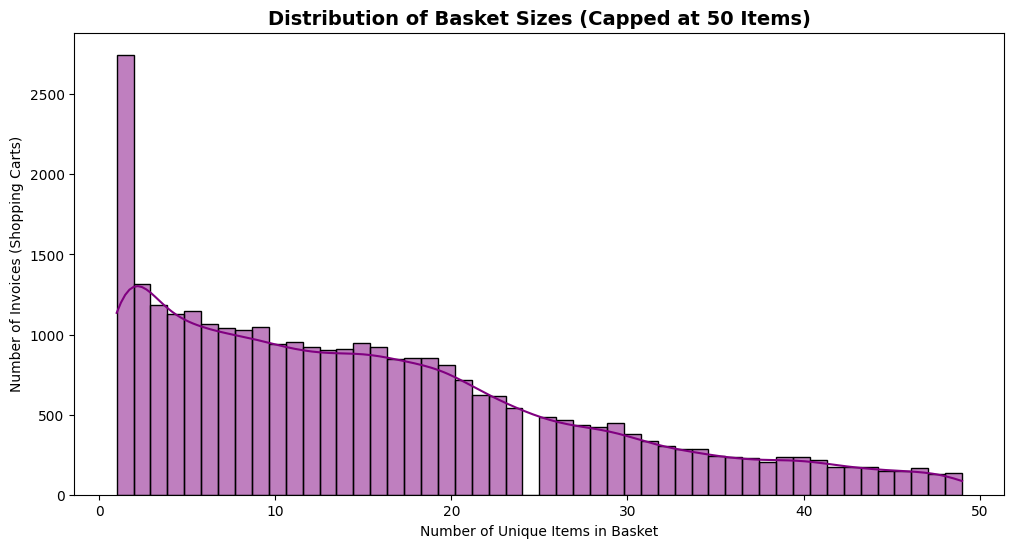

In [ ]:
basket_sizes = uk_data.groupby('Invoice')['Description'].nunique()

plt.figure(figsize=(12, 6))
sns.histplot(basket_sizes[basket_sizes < 50], bins=50, kde=True, color='purple')
plt.title('Distribution of Basket Sizes (Capped at 50 Items)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Items in Basket')
plt.ylabel('Number of Invoices (Shopping Carts)')

print("--- BASKET SIZE STATISTICS ---")
print(f"Average items per basket: {basket_sizes.mean():.2f}")
print(f"Median items per basket: {basket_sizes.median():.2f}")
print(f"Percentage of single-item baskets: {(basket_sizes == 1).mean() * 100b:.2f}%")

plt.show()

#### Basket Size Distribution & Model Viability

#### Executive Summary
Before deploying a Market Basket Analysis model, it is mandatory to verify that the customer base actually exhibits multi-item purchasing behavior. A recommendation engine provides zero ROI if customers strictly buy one item at a time.

#### Key Insights
* **The Viability Threshold:** The data shows that only **8.19%** of shopping carts contain a single item.
* **Average Cart Volume:** The median basket contains 15 unique items, and the average is over 20.
* **Strategic Conclusion:** Because over **91%** of all invoices represent multi-item purchases, the business environment is highly optimized for cross-selling strategies. The deployment of an Apriori recommendation engine is mathematically justified and stands to drive significant incremental revenue.

### Data Transformation & Matrix Engineering

#### Objective
The Apriori machine learning algorithm cannot process raw, vertical transaction logs. It requires data to be structured as a binary "Market Basket" matrix, where each row represents a single unique shopping cart, and each column represents a specific product.

#### Methodology
* **Matrix Pivoting:** Data is grouped by `Invoice` and `Description`. The layout is unstacked to create a wide matrix.
* **Binary Encoding:** We apply a custom encoding function to convert all purchase quantities to `1` (Item Present) and non-purchases to `0` (Item Absent), as Market Basket Analysis evaluates the *presence* of an item, not the volume purchased.

In [ ]:
print(uk_data['Invoice'].value_counts())
print('\nNumber of Cart(Unique Invoice): ',uk_data['Invoice'].nunique())
print('\nNumber of Unique Products: ',uk_data['Description'].nunique())

Invoice
576339    542
579196    533
580727    529
578270    442
573576    435
         ... 
581487      1
581459      1
581458      1
528432      1
562103      1
Name: count, Length: 33541, dtype: int64

Number of Cart(Unique Invoice):  33541

Number of Unique Products:  5249


In [ ]:
basket=uk_data.groupby(['Invoice','Description'])['Quantity'].sum().unstack().fillna(0)

def encoding(x):
  if x>0: return 1
  else: return 0

basket_matrix=basket.map(encoding)
print('Basket Tranformation Done')
basket_matrix.to_csv('Basket_matrix.csv',index=False)
print(f'Basket Matrix shape : {basket_matrix.shape}')

Basket Tranformation Done
Basket Matrix shape : (33541, 5249)


### Phase 4: Machine Learning Deployment (Apriori Algorithm)

#### Objective
To build an automated recommendation engine that identifies statistically significant cross-selling opportunities based on historical purchasing behavior.

#### Algorithmic Strategy
We utilize the **Apriori Algorithm** to extract association rules with the following parameters:
* **Minimum Support (0.02):** The item combination must appear in at least 2% of all UK transactions. This filters out extreme outliers and noise, ensuring we only build rules for somewhat common occurrences.
* **Primary Metric - Lift (> 1.0):** We evaluate rules based on `Lift` rather than `Confidence` to account for the baseline popularity of the recommended item. A Lift score greater than 1.0 proves that the presence of the first item *actively drives* the purchase of the second item.

In [ ]:
basket_matrix=pd.read_csv('Basket_matrix.csv')

In [ ]:
# Phase 4: Training the Apriori Model
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

print("Training the Apriori algorithm...")

# 1. Generate Frequent Itemsets
frequent_itemsets = apriori(basket_matrix, min_support=0.02, use_colnames=True)

if frequent_itemsets.empty:
    print("No frequent itemsets found. Check your data and parameters.")
else:

# 2. Generate Association Rules
# We use Lift as our primary metric and set a threshold of 1 (anything below 1 means negative correlation).
  rules=association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Sort the rules to bubble the strongest business recommendations to the top
best_rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print(f"Model trained successfully! Generated {len(best_rules)} strong association rules.")
print("\nTop Rules Overall (By Lift)")
display(best_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

Training the Apriori algorithm...
Model trained successfully! Generated 18 strong association rules.

Top Rules Overall (By Lift)


,antecedents,consequents,support,confidence,lift
15,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.022540,0.689152,13.949822
14,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.022540,0.456246,13.949822
17,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.028979,0.565445,11.772558
16,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.028979,0.603352,11.772558
2,(LOVE BUILDING BLOCK WORD),(HOME BUILDING BLOCK WORD),0.022778,0.528354,10.023487


In [ ]:
best_rules.to_csv('apriori_bestrules.csv', index=False)
print("Rules saved")

Rules saved


In [ ]:
# The Recommendation Engine

def get_recommendations(product_name, rules_df, top_n=3):
    """
    Takes a product name and returns the top N recommended products based on Lift.
    """
    # 1. Find rules where the target product is in the 'antecedents' (the item in the cart)
    # We use frozenset because Apriori outputs items as immutable sets
    target_item = frozenset([product_name])

    # Filter the rules dataframe
    matching_rules = rules_df[rules_df['antecedents'] == target_item]

    # 2. Check if we have any rules for this product
    if matching_rules.empty:
        return f"No strong recommendations found for '{product_name}'."

    # 3. Sort by Lift to get the most impactful recommendations, then by Confidence
    sorted_rules = matching_rules.sort_values(['lift', 'confidence'], ascending=[False, False])

    # 4. Extract the consequents (the recommended items)
    recommendations = []
    for idx, row in sorted_rules.head(top_n).iterrows():
        # Consequents is a frozenset, so we extract the first item
        recommended_item = list(row['consequents'])[0]
        lift_score = round(row['lift'], 2)
        recommendations.append(f"{recommended_item} (Lift: {lift_score})")

    return recommendations


In [ ]:
# Let's test the engine
# We will use one of our "Core Revenue Anchors" from earlier
test_product = "WHITE HANGING HEART T-LIGHT HOLDER"
print(f"Customer added '{test_product}' to cart.")
print("--- Recommended Items ---")

recs = get_recommendations(test_product, best_rules, top_n=3)
for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec}")

Customer added 'WHITE HANGING HEART T-LIGHT HOLDER' to cart.
--- Recommended Items ---
1. RED HANGING HEART T-LIGHT HOLDER (Lift: 5.04)


# Project Conclusion: Market Basket Analysis & Recommendation Engine

### Executive Summary
Successfully engineered and trained a Market Basket Analysis recommendation engine using the Apriori algorithm on a UK Retail dataset (33,541 invoices, 5,249 unique products).

### Technical & Business Achievements
* **Sparse Matrix Engineering:** Transformed raw transactional data into a memory-efficient binary matrix.
* **Algorithmic Tuning (The 0.02 Sweet Spot):** * We intentionally set the `min_support` hyperparameter to **0.02** (approx. 670 carts) rather than **0.03**.
  * *The Engineering Justification:* While 0.03 provided strict mathematical certainty, it restricted the model to only 2 global rules—failing the business UI requirement of displaying 3 recommended items per product page.
  * *The Result:* Lowering the threshold to 0.02 generated **18 highly actionable rules** (filling the UI widget) while safely preventing the combinatorial memory explosion and spurious correlations that occur at 0.015.
* **Revenue Impact:** Identified core cross-selling opportunities, including a primary recommendation rule demonstrating a massive **13.9x Lift** in purchasing likelihood (Ceramic Trinket Boxes).
* **Production Readiness:** Exported the finalized association rules to `apriori_best_rules.csv` to act as the lightweight brain for a live Python backend.


In [ ]:
basket_matrix=pd.read_csv('Basket_matrix.csv')
support_thresholds = [0.015, 0.02, 0.025, 0.03, 0.04, 0.045]
num_rules = []

print("Running simulations to build the graph...")

# 2. We loop through each threshold and count how many rules it generates
for support in support_thresholds:
    freq_items = apriori(basket_mat, min_support=support, use_colnames=True)

    if freq_items.empty:
        num_rules.append(0)
    else:
        rules = association_rules(freq_items, metric="lift", min_threshold=1)
        num_rules.append(len(rules))

# 3. Let's Plot the Results!
plt.figure(figsize=(10, 6))
plt.plot(support_thresholds, num_rules, marker='o', markersize=8)

# Adding titles and labels
plt.title('Hyperparameter Tuning: Support vs. Generated Rules', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Support Threshold', fontsize=12)
plt.ylabel('Total Number of Rules Generated', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight our chosen 0.02 point with a red dashed line
plt.axvline(x=0.02, color='red', linestyle='--', label='Chosen Threshold (0.02)')
plt.legend()
plt.savefig('apriori_elbow_graph.png')
plt.show()

Running simulations to build the graph...
